# Self-Guided Deep Image Prior (DIP) for MRI Reconstruction

This notebook implements a self-guided DIP approach for MRI reconstruction. It uses a U-Net architecture to generate the image from a latent code, optimizing both the network parameters and the latent code to match the measured k-space data.


In [1]:
# Import necessary libraries for MRI reconstruction and deep learning
import numpy as np
import matplotlib.pyplot as plt
import torch
from unet import UNet, FullUNet, MediumUNet, OneLayerUNet, ExtraDeepUNet, SuperDeepUNet
import torch.optim as optim
import torch.fft as fft
import torch.nn as nn
from tqdm.notebook import tqdm
import sigpy as sp
import sigpy.mri as mr
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
import glob
import two_channel_dataset_DIP_github
from torch.nn import init
from torch.autograd import Variable

## 1. Data Loading
Load the test dataset, including k-space data, sensitivity maps, and sampling masks.


In [2]:
# Load test data from the dataset loader
# Prepare k-space data and sensitivity maps
for test_direct,test_target,test_smap,test_mask,test_mask_in,no_crop_smap,test_kspace in two_channel_dataset_DIP_github.test_loader:
    k_np =test_kspace
    A_k_ref = k_np[:,:, 0, :, :] + 1j * k_np[:,:, 1, :, :]
    sense_maps_ref = no_crop_smap[:,:, 0, :, :] + 1j *no_crop_smap[:,:, 1, :, :]
    mask_from_file = test_mask_in[0].float()
    print(mask_from_file.shape)

torch.Size([640, 372])


## 2. Helper Functions & Device Setup
Define FFT/IFFT utilities, weight initialization, and set the computation device.


In [3]:
# Define function to initialize network weights
def init_weights(net, init_type='normal', init_gain=0.02):
    def init_func(m):  # define the initialization function
        classname = m.__class__.__name__
        if hasattr(m, 'weight') and (classname.find('Conv') != -1 or classname.find('Linear') != -1):
            if init_type == 'normal':
                init.normal_(m.weight.data, 0.0, init_gain)
            elif init_type == 'xavier':
                init.xavier_normal_(m.weight.data, gain=init_gain)
            elif init_type == 'kaiming':
                init.kaiming_normal_(m.weight.data, a=0, mode='fan_in')
            elif init_type == 'orthogonal':
                init.orthogonal_(m.weight.data, gain=init_gain)
            else:
                raise NotImplementedError('initialization method [%s] is not implemented' % init_type)
            if hasattr(m, 'bias') and m.bias is not None:
                init.constant_(m.bias.data, 0.0)
        elif classname.find('BatchNorm2d') != -1:  # BatchNorm Layer's weight is not a matrix; only normal distribution applies.
            init.normal_(m.weight.data, 1.0, init_gain)
            init.constant_(m.bias.data, 0.0)

    print('initialize network with %s' % init_type)
    net.apply(init_func)  # apply the initialization function <init_func>


In [4]:
# Helper functions for FFT/IFFT with shifts and conversions between k-space/image domain
def fft_with_shifts(img):
    return fft.fftshift(fft.fft2(fft.ifftshift(img)))

def ifft_with_shifts(ksp):
    return fft.fftshift(fft.ifft2(fft.ifftshift(ksp)))

def ksp_and_mps_to_gt(ksp, mps):
    gt = mps.conj() * ifft_with_shifts(ksp)
    gt = torch.sum(gt, axis=0)
    return gt

def mps_and_gt_to_ksp(mps, gt):
    ksp = fft_with_shifts(mps * gt)
    return ksp

In [5]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## 3. Model Configuration
Initialize the `ExtraDeepUNet` model, optimizer, and loss function.


In [6]:
# Initialize the ExtraDeepUNet model and set hyperparameters
net = ExtraDeepUNet(n_channels=2, n_classes=2).to(device)
#net= nn.DataParallel(net).to(device)
init_weights(net, init_type='normal',init_gain=0.02)
num_epochs = 500
learning_rate = 3e-4
show_every = 50

initialize network with normal


In [7]:
# Setup Optimizer and Loss Function
optimizer = optim.Adam(net.parameters(), lr = learning_rate)

criterion = nn.L1Loss()

## 4. Experiment Preparation
Prepare the specific test instance, ground truth, and initial reference input.


In [8]:
# Prepare specific test instance and latent reference
ksp1 = A_k_ref[0]

mps1 = sense_maps_ref[0]

new_ref = ksp_and_mps_to_gt(mask_from_file * ksp1, mps1)

ref = torch.zeros(1,2,640,372)
ref[:,0,:,:] = new_ref.real
ref[:,1,:,:] = new_ref.imag

# Create a learnable reference input (z) initialized with random noise
ref = Variable(torch.rand((1,2,640,372)).to(device), requires_grad=True)

optimizer2 = optim.Adam([ref], lr = 1e-1)

In [9]:
# Calculate scale factor to match network output magnitude with target k-space
with torch.no_grad():
    scale_factor = torch.linalg.norm(net(ref.to(device)))/torch.linalg.norm(ksp_and_mps_to_gt(ksp1, mps1).to(device))
    target_ksp = scale_factor * ksp1.to(device)
    print('K-space scaled by: ', scale_factor)

K-space scaled by:  tensor(5531.6768, device='cuda:0')


In [10]:
# Compute and Normalize Ground Truth
gt1 = ksp_and_mps_to_gt(ksp1, mps1)

gt1 = torch.abs(gt1)/torch.max(torch.abs(gt1))

\begin{equation}
    \underset{\theta,z}{\min} \|MFS(\theta(z+\sigma)-y)\|_1 + \|(\theta(z+\sigma)-z)\|_1
\end{equation}

In [17]:
# Initialize Training Variables and Hyperparameters
img_map = torch.sum(torch.abs(mps1), axis=0) > 0
img_map = img_map.to(device)

MSE = nn.MSELoss()

mask_from_file = mask_from_file.clone().detach().to(dtype=torch.complex64, device=device)

mps1 = mps1.to(device)

alpha = 2
avg_ksp = torch.zeros_like(ksp1)
avg_ksp = avg_ksp.to(device)

## 5. Reconstruction Loop
Main optimization loop. The loss includes a data consistency term and a self-guidance regularization term.


> **Note:** This notebook uses `tqdm.notebook` for an interactive progress bar. It may not be visible when viewing the notebook statically on GitHub. Please run the notebook locally to see the progress bar.

In [12]:
# Define Root Mean Square Error (RMSE) function
def rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())

  0%|          | 0/4000 [00:00<?, ?it/s]

/tmp/ipykernel_3071376/3061019919.py:42: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  psnr = compute_psnr(np.array(gt1, dtype=np.float32), np.array(out))
/tmp/ipykernel_3071376/3061019919.py:48: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  avg_psnr = compute_psnr(np.array(gt1), np.array(out_avg)/float(out_avg.max().item()))


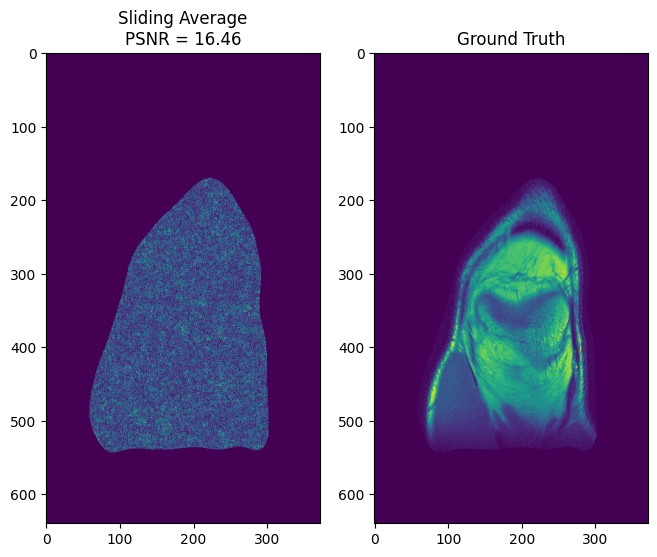

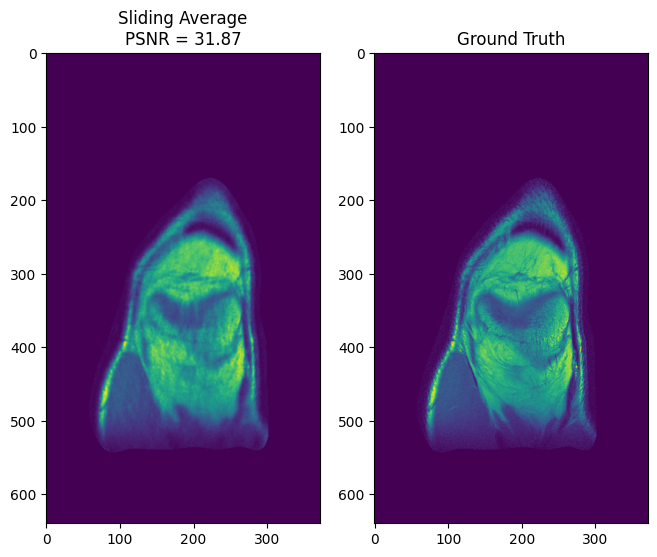

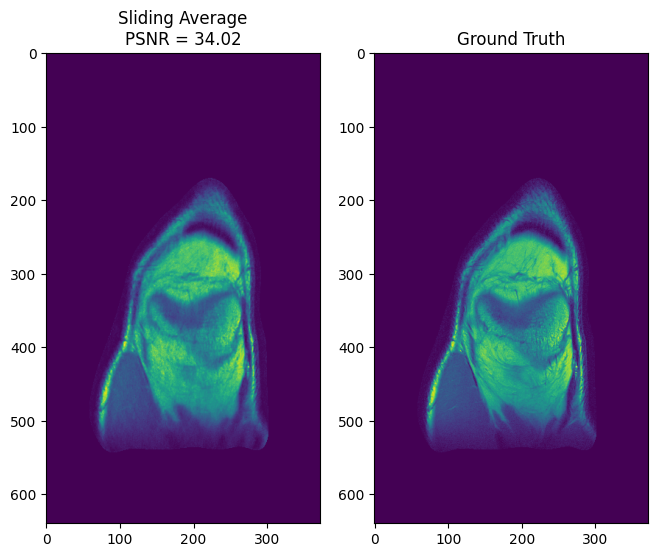

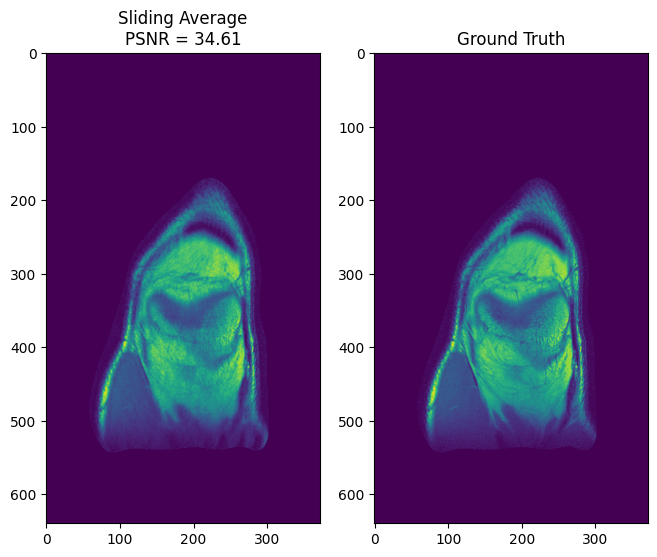

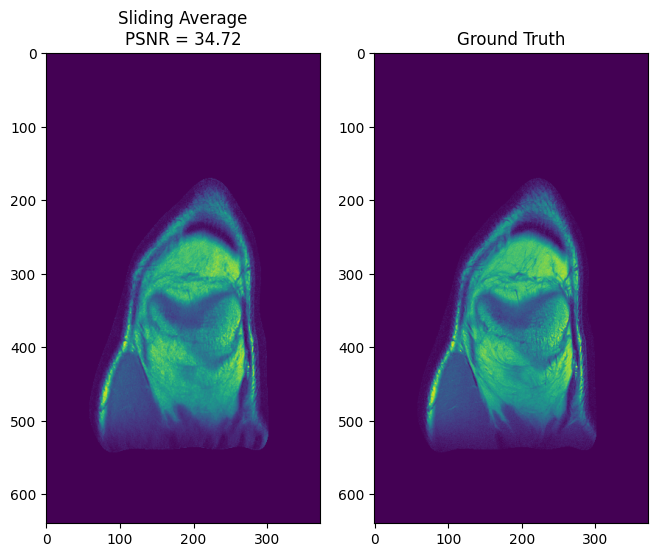

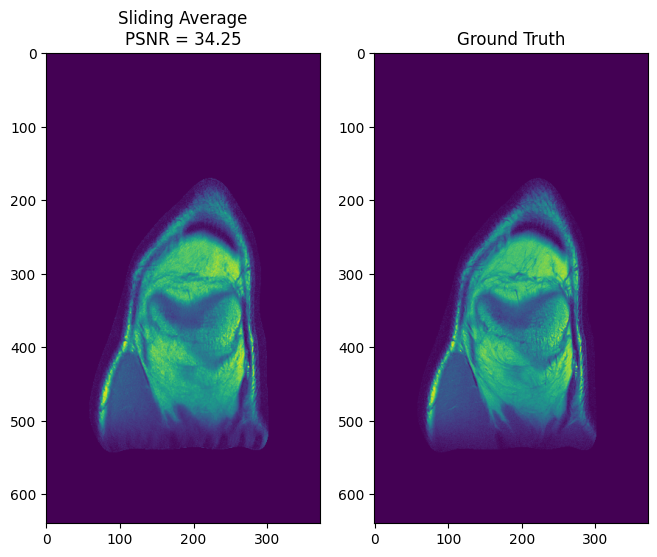

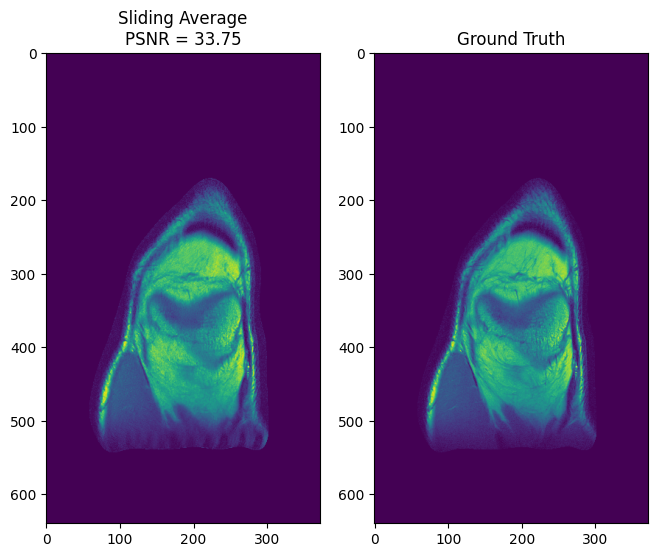

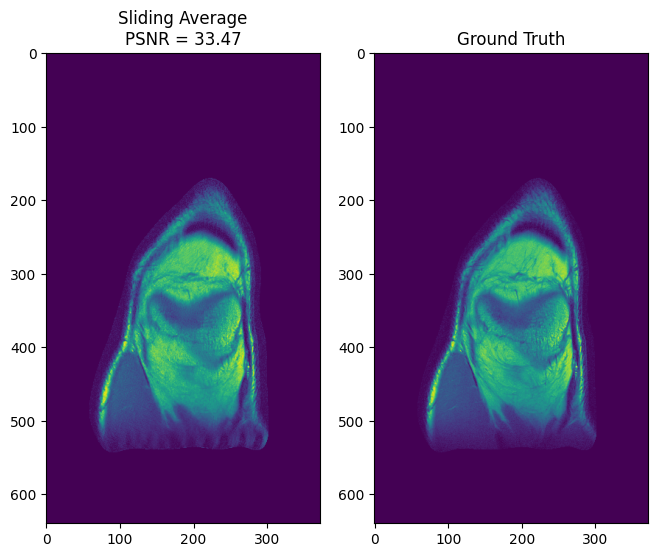

In [ ]:
# Main optimization loop for Self-Guided DIP
losses = []
psnrs = []
avg_psnrs = []
exp_weight = .99
out_avg = torch.zeros_like(torch.abs(gt1))#.to(device)

show_every = 500 

for epoch in tqdm(range(4000)):
    # Zero gradients for both optimizers
    optimizer.zero_grad()
    optimizer2.zero_grad()
    noise_max = torch.max(ref)/2
    random_smoothing_temp = torch.zeros_like(ref).to(device)
    for jj in range(3):
        # Inject noise for robustness/smoothing
        noise = noise_max * torch.rand(*ref.shape, device=device)
    
        # Forward pass with noise injection
        net_output = net(ref + noise).squeeze()
        random_smoothing_temp += net_output
    net_output_final = random_smoothing_temp/3
    #print(net_output_final.shape)
    net_output_final = torch.view_as_complex(net_output_final.squeeze().permute(1,2,0).contiguous())
    
    # Convert network output to k-space
    pred_ksp = mps_and_gt_to_ksp(mps1, net_output_final)
    
    # Compute Loss: Data Consistency + Self-Guidance Regularization
    loss = torch.linalg.norm(mask_from_file * target_ksp - mask_from_file * pred_ksp.squeeze()) \
           + alpha * torch.linalg.norm(ref - net_output_final)
    
    
    # Backpropagation
    loss.backward()
    optimizer.step()
    optimizer2.step()
    with torch.no_grad():
        out = torch.abs(ksp_and_mps_to_gt(pred_ksp.detach(), mps1)).squeeze().cpu()
        out /= torch.max(out)
        psnr = compute_psnr(np.array(gt1, dtype=np.float32), np.array(out))
        psnrs.append(psnr)

        losses.append(loss.item())

        out_avg = out_avg * exp_weight + out * (1 - exp_weight)
        avg_psnr = compute_psnr(np.array(gt1), np.array(out_avg)/float(out_avg.max().item()))
        avg_psnrs.append(avg_psnr)
        
        avg_ksp = avg_ksp * exp_weight + pred_ksp * (1 - exp_weight)

        if epoch%show_every == 0:
            plt.figure(figsize=(12,12))
            plt.subplot(131)
            plt.imshow(out_avg.cpu())
            plt.title('Sliding Average\nPSNR = ' + str(round(avg_psnr, 2)))
            plt.colorbar()
        
            plt.subplot(132)
            plt.imshow(np.abs(gt1.numpy()))
            plt.title('Ground Truth')
            # plt.colorbar()
                            
            plt.show()

torch.Size([320, 320])


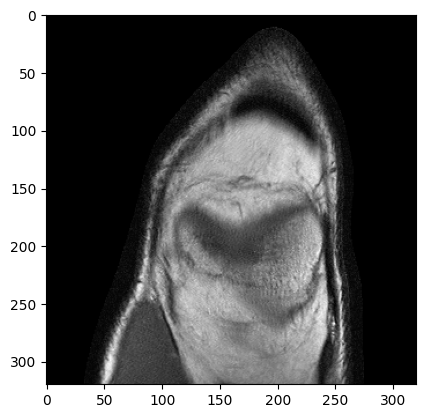

In [15]:
nx = 640
ny = 372
reshape_out_avg = out_avg[ nx // 2 - 160:nx // 2 + 160, ny // 2 - 160:ny // 2 + 160].cpu()

print(reshape_out_avg.shape) 

import matplotlib.pyplot as plt
plt.imshow(reshape_out_avg, cmap='gray')
plt.show()